# Fit the Selsing Composite with an SMC-like Reddened Continuum

This tutorial fits the Selsing quasar composite using a custom continuum component that combines a power law with a simple SMC-like UV reddening curve. The goal is to show how to replace the built-in AGN power law with a reddened continuum model using `custom_components`.

The attenuation law used here is intentionally **SMC-like**, not an exact Pei (1992) or Gordon et al. extinction curve. It is a compact tutorial example that captures the main behavior: stronger attenuation toward the UV.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

import jax.numpy as jnp

from jaxqsofit import QSOFit, build_default_prior_config
from jaxqsofit.custom_components import make_custom_component

In [2]:
def smc_like_reddened_powerlaw(wave, params, metadata):
    """Return a power law multiplied by a smooth SMC-like reddening curve."""
    wave = jnp.asarray(wave)
    pivot = jnp.asarray(float(metadata.get("pivot", 3000.0)))
    uv_ref = jnp.asarray(float(metadata.get("uv_ref", 2500.0)))
    alpha = jnp.asarray(float(metadata.get("alpha", 1.2)))

    x = jnp.clip(wave / pivot, 1e-8, None)
    intrinsic = params["norm"] * x ** params["slope"]

    ebv = jnp.maximum(params["ebv"], 0.0)
    k_lambda = (jnp.clip(wave, 1e-8, None) / uv_ref) ** (-alpha)
    attenuation = 10.0 ** (-0.4 * ebv * k_lambda)
    return intrinsic * attenuation


reddened_pl = make_custom_component(
    name="smc_like_reddened_pl",
    parameter_priors={
        "norm": {"dist": "LogNormal", "loc": np.log(10.0), "scale": 0.5},
        "slope": {"dist": "Normal", "loc": -1.5, "scale": 0.5},
        "ebv": {"dist": "HalfNormal", "scale": 0.3},
    },
    evaluate=smc_like_reddened_powerlaw,
    metadata={
        "pivot": 3000.0,
        "uv_ref": 2500.0,
        "alpha": 1.2,
    },
)

In [3]:
data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)
fn = data_dir / "Selsing2015.dat"
if not fn.exists():
    url = "https://raw.githubusercontent.com/jselsing/QuasarComposite/master/Selsing2015.dat"
    urlretrieve(url, fn)

arr = np.loadtxt(fn)
lam = arr[:, 0].astype(float)
flux = arr[:, 1].astype(float)
err = arr[:, 2].astype(float) if arr.shape[1] >= 3 else np.full_like(flux, 1e-3 * np.nanmedian(np.abs(flux)))

m = np.isfinite(lam) & np.isfinite(flux) & np.isfinite(err) & (lam > 0) & (err > 0)
lam, flux, err = lam[m], flux[m], err[m]
print(f"Loaded {lam.size} pixels from {fn}")

Loaded 25118 pixels from data/Selsing2015.dat


100%|██████████| 800/800 [00:19<00:00, 40.60it/s, init loss: 1997634.1388, avg. loss [761-800]: -18271.1385]


max data        : 56.5312
max total model : 48.296857277177224
max PL          : 0.0
max host        : 0.0
max FeII UV     : 1.2258537165263677
max FeII opt    : 0.21251094137771356
max Balmer cont : 0.0
max lines       : 32.96087041959811
max smc_like_reddened_pl: 18.034562644232878


sample: 100%|██████████| 80/80 [06:30<00:00,  4.88s/it, 255 steps of size 2.24e-04. acc. prob=0.97]


max data        : 56.5312
max total model : 48.52096418478358
max PL          : 0.0
max host        : 0.0
max FeII UV     : 1.227127908625422
max FeII opt    : 0.21340796649104127
max Balmer cont : 0.0
max lines       : 33.13974669763401
max smc_like_reddened_pl: 18.087492307436833


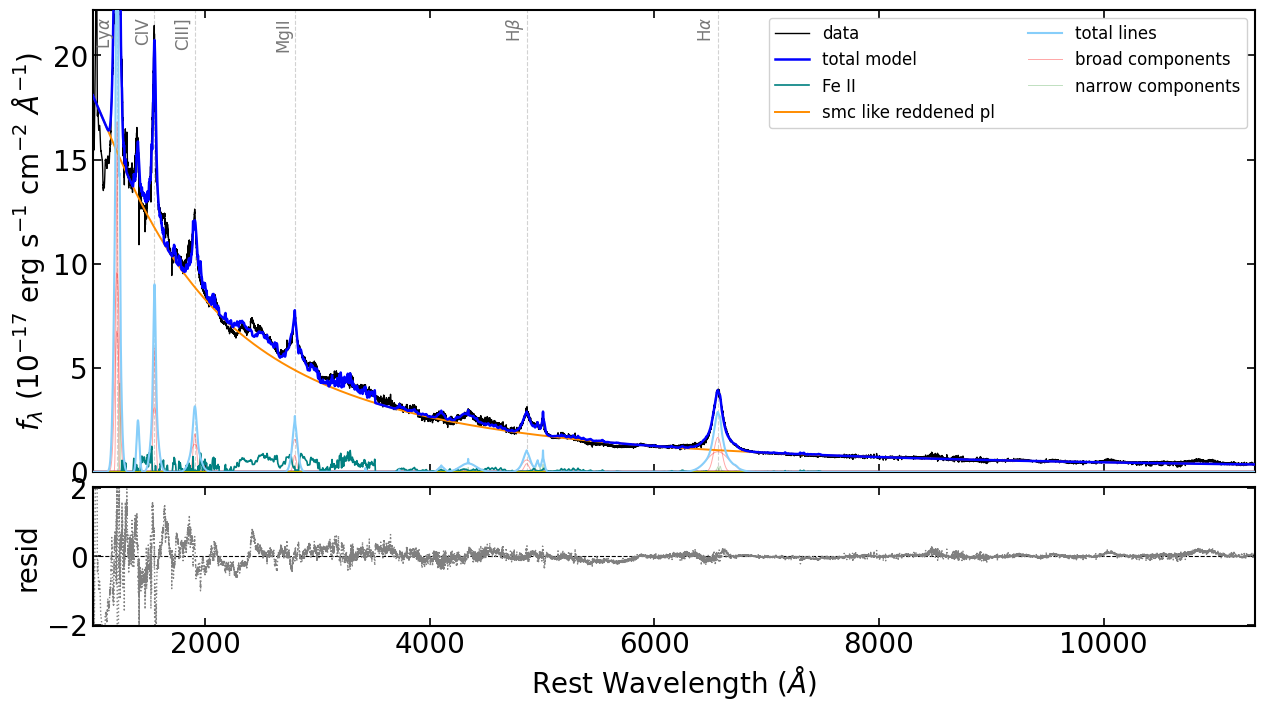

In [11]:
q = QSOFit(lam=lam, flux=flux, err=err, z=0.0)

prior_config = build_default_prior_config(
    flux=flux,
    include_elg_narrow_lines=False,
    include_high_ionization_lines=False,
)

# Disable the built-in AGN power law and fit a custom reddened continuum instead.
q.fit(
    deredden=False,
    fit_method="optax+nuts",
    fit_lines=True,
    decompose_host=False,
    fit_pl=False,
    fit_fe=True,
    fit_bc=False,
    fit_poly=False,
    mask_lya_forest=False,
    prior_config=prior_config,
    dsps_ssp_fn="../tempdata.h5",
    custom_components=[reddened_pl],
    nuts_warmup=20,
    nuts_samples=60,
    nuts_chains=1,
    nuts_target_accept=0.9,
    optax_steps=1200,
    optax_lr=1e-2,
    save_result=False,
    plot_fig=True,
    save_fig=False,
    verbose=True,
)

In [15]:
mask_lyman_forest = q.wave > 1215.67

resid = np.asarray(q.flux) - np.asarray(q.model_total)
sigma = np.asarray(q.err)

# include fitted jitter (recommended)
if q.numpyro_samples is not None:
    s = q.numpyro_samples
    frac_j = float(np.median(np.asarray(s.get("frac_jitter", 0.0))))
    add_j  = float(np.median(np.asarray(s.get("add_jitter", 0.0))))
    sigma = np.sqrt(sigma**2 + (frac_j*np.abs(np.asarray(q.model_total)))**2 + add_j**2)

m = np.isfinite(resid) & np.isfinite(sigma) & (sigma > 0) & mask_lyman_forest
z = resid[m] / sigma[m]

chi2 = float(np.sum(z**2))
chi2_per_pixel = float(np.mean(z**2))      # more stable than reduced chi2 here
wrms = float(np.sqrt(np.mean(z**2)))

print("chi2:", chi2)
print("chi2_per_pixel:", chi2_per_pixel)
print("wrms (normalized residual std):", wrms)


chi2: 45808.221135921296
chi2_per_pixel: 1.863713785586122
wrms (normalized residual std): 1.365179030598596


In [12]:
samples = q.numpyro_samples
print("median custom slope:", float(np.median(samples["custom_smc_like_reddened_pl_slope"])))
print("median custom ebv  :", float(np.median(samples["custom_smc_like_reddened_pl_ebv"])))

median custom slope: -2.065258644734474
median custom ebv  : 0.4162095453234011


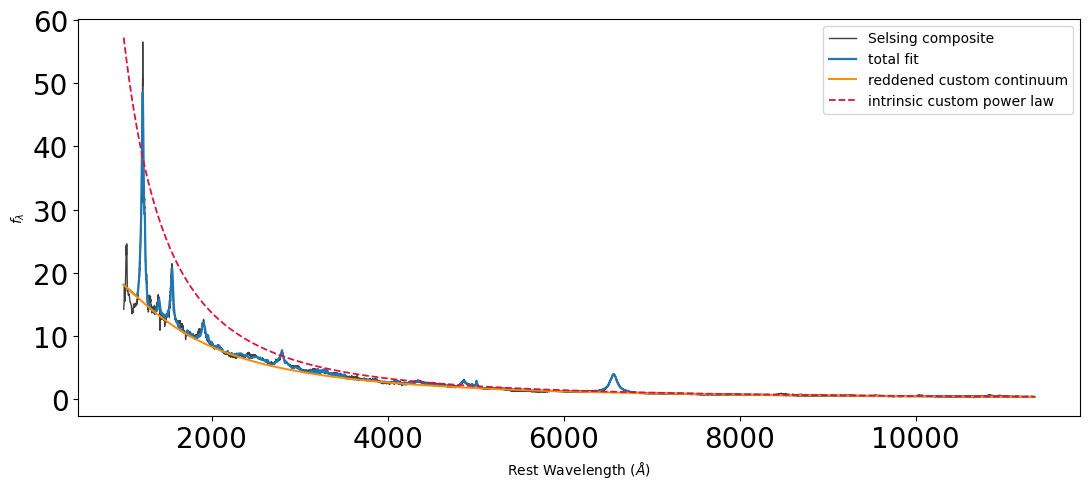

In [13]:
norm_draws = np.asarray(samples["custom_smc_like_reddened_pl_norm"], dtype=float).reshape(-1)
slope_draws = np.asarray(samples["custom_smc_like_reddened_pl_slope"], dtype=float).reshape(-1)
pivot = 3000.0
x = np.clip(q.wave / pivot, 1e-8, None)
intrinsic_draws = norm_draws[:, None] * x[None, :] ** slope_draws[:, None]
intrinsic_med = np.median(intrinsic_draws, axis=0)
intrinsic_lo, intrinsic_hi = np.percentile(intrinsic_draws, [16, 84], axis=0)

reddened_med = np.asarray(q.custom_components["smc_like_reddened_pl"], dtype=float)

plt.figure(figsize=(11, 5))
plt.plot(q.wave, q.flux, color="k", lw=1.0, alpha=0.75, label="Selsing composite")
plt.plot(q.wave, q.model_total, color="tab:blue", lw=1.6, label="total fit")
plt.plot(q.wave, reddened_med, color="darkorange", lw=1.4, label="reddened custom continuum")
plt.plot(q.wave, intrinsic_med, color="crimson", lw=1.3, ls="--", label="intrinsic custom power law")
plt.fill_between(q.wave, intrinsic_lo, intrinsic_hi, color="crimson", alpha=0.12, linewidth=0)
plt.xlabel(r"Rest Wavelength ($\AA$)")
plt.ylabel(r"$f_\lambda$")
plt.legend(frameon=True)
plt.tight_layout()

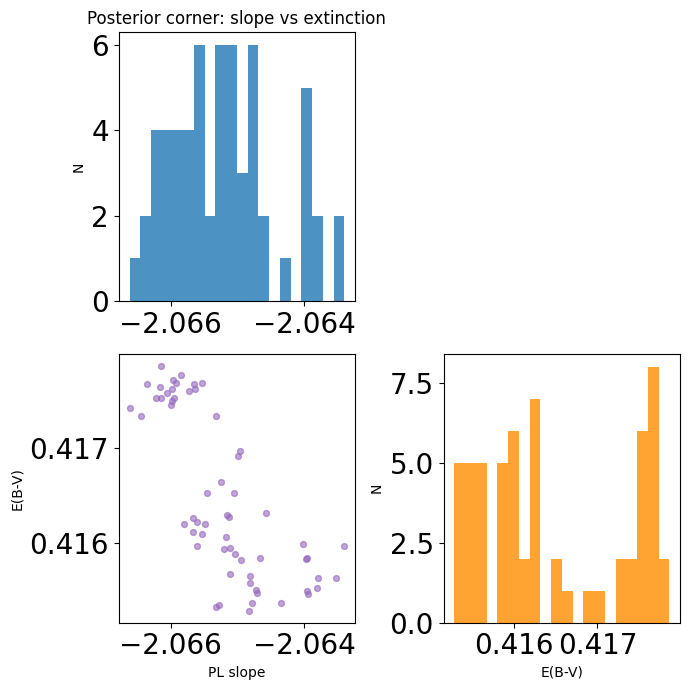

In [14]:
# Corner-style plot for custom PL slope vs extinction level E(B-V)
pl_slope = np.asarray(samples["custom_smc_like_reddened_pl_slope"], dtype=float).ravel()
ebv = np.asarray(samples["custom_smc_like_reddened_pl_ebv"], dtype=float).ravel()

fig, ax = plt.subplots(2, 2, figsize=(7, 7))

# 1D histogram: PL slope
ax[0, 0].hist(pl_slope, bins=20, color="tab:blue", alpha=0.8)
ax[0, 0].set_ylabel("N")
ax[0, 0].set_title("Posterior corner: slope vs extinction")

# Empty upper-right panel (corner layout)
ax[0, 1].axis("off")

# 2D scatter: slope vs E(B-V)
ax[1, 0].scatter(pl_slope, ebv, s=18, alpha=0.6, color="tab:purple")
ax[1, 0].set_xlabel("PL slope")
ax[1, 0].set_ylabel("E(B-V)")

# 1D histogram: E(B-V)
ax[1, 1].hist(ebv, bins=20, color="darkorange", alpha=0.8)
ax[1, 1].set_xlabel("E(B-V)")
ax[1, 1].set_ylabel("N")

plt.tight_layout()
plt.show()

## Notes

- This tutorial uses a **custom continuum component** instead of the built-in AGN power law.
- The reddening curve is only meant to be **SMC-like**: it steepens into the UV and attenuates the continuum smoothly.
- If you want a physically calibrated extinction law, the next step would be to promote a specific SMC law into a reusable evaluator and compare it against this simplified version.